# How has collaboration in scientific research changed across arXiv fields over time? 

## 1. Has the average size of research teams changed over time across different arXiv fields?
Find whether papers are being written by larger teams than they used to be.



## Set Up File Paths

The cleaned CSV is in `data/processed`. If it is missing, incomplete, or uses older sampling settings, the notebook rebuilds it from the raw arXiv metadata using the cleaning script in `scripts`.


In [8]:
from pathlib import Path
import sys


def find_project_root(start=Path.cwd()):
    for folder in [start, *start.parents]:
        if (folder / "data").exists() and (folder / "scripts").exists():
            return folder
    raise FileNotFoundError("Could not find the project folder with data/ and scripts/.")


PROJECT_ROOT = find_project_root()
RAW_FILE = PROJECT_ROOT / "data" / "raw" / "arxiv-metadata-oai-snapshot.zip"
CLEAN_FILE = PROJECT_ROOT / "data" / "processed" / "arxiv_metadata_clean.csv"
SCRIPTS_DIR = PROJECT_ROOT / "scripts"

if str(SCRIPTS_DIR) not in sys.path:
    sys.path.append(str(SCRIPTS_DIR))

print(f"Project folder: {PROJECT_ROOT}")
print(f"Clean data file: {CLEAN_FILE}")

Project folder: /Users/mudmi/Desktop/applied_ds_capstone
Clean data file: /Users/mudmi/Desktop/applied_ds_capstone/data/processed/arxiv_metadata_clean.csv


## Get Clean Data

This step keeps up to 1,000 papers per year and primary category with complete essential fields, including authors. It reuses a completed sample and the existing raw download.


In [ ]:
import importlib
import clean_arxiv

clean_arxiv = importlib.reload(clean_arxiv)

if not clean_arxiv.clean_file_is_current(CLEAN_FILE):
    clean_arxiv.run_full(raw_file=RAW_FILE, clean_file=CLEAN_FILE)
else:
    print("Complete year/category sample already exists")

Using existing full snapshot: /Users/mudmi/Desktop/applied_ds_capstone/data/raw/arxiv-metadata-oai-snapshot.zip


## Load Only the Needed Columns for This SubQuestion
paper ID, year, category, authors


In [ ]:
import pandas as pd

cols = ["paper_id", "submitted_year", "primary_category", "authors"]
papers = pd.read_csv(CLEAN_FILE, usecols=cols, dtype={"paper_id": str})

papers.head()

,paper_id,submitted_year,primary_category,authors
0,704.0001,2007,hep-ph,"C. Bal\'azs, E. L. Berger, P. M. Nadolsky, C.-..."
1,704.0002,2007,math.CO,Ileana Streinu and Louis Theran
2,704.0003,2007,physics.gen-ph,Hongjun Pan
3,704.0004,2007,math.CO,David Callan
4,704.0005,2007,math.CA,Wael Abu-Shammala and Alberto Torchinsky


In [ ]:
print(f"Rows: {papers.shape[0]:,}")
print(f"Years: {papers['submitted_year'].min()} to {papers['submitted_year'].max()}")

Rows: 3,156,710
Years: 1986 to 2026


## Count Authors and Create a Broad Field

- split author names at `,` and `and`
- keep at least 1 author when the author text is present

- Broad Field examples: `cs.AI` -> `cs` , `math.CO` -> `math`


In [ ]:
import re


def count_authors(author_text):
    text = str(author_text).strip()
    if not text:
        return 0

    text = re.sub(r"\s+and\s+", ", ", text)
    authors = [name.strip() for name in text.split(",") if name.strip()]
    return max(1, len(authors))


def broad_field(category):
    if pd.isna(category):
        return "unknown"
    return str(category).split(".")[0]


df = papers.copy()
df["submitted_year"] = pd.to_numeric(papers["submitted_year"], errors="coerce")
df = df.dropna(subset=["submitted_year", "primary_category", "authors"]).copy()
df["submitted_year"] = df["submitted_year"].astype(int)
df["author_count"] = df["authors"].apply(count_authors)
df["field"] = df["primary_category"].apply(broad_field)

df[["paper_id", "submitted_year", "primary_category", "field", "author_count"]].head()

NameError: name 'mira' is not defined

## Select the Years for the Trend

The trend analysis uses 1992 through 2026. The 2026 data covers a partial year, so interpret that year's results with this in mind.


In [ ]:
analysis = df[
    (df["submitted_year"].between(1992, 2026))
    & (df["author_count"] > 0)
].copy()

print(f"Papers used in Mira's analysis: {len(analysis):,}")


Papers used in Mira's analysis: 2,922,493
Years used: 1992 to 2025


## Overall Team Size Over Time

The mean shows the average number of authors. The median shows the middle paper. The median is useful because a few very large physics collaborations can make the average much higher.


In [ ]:
overall_by_year = (
    analysis.groupby("submitted_year")["author_count"]
    .agg(papers="count", mean_authors="mean", median_authors="median")
    .reset_index()
)

overall_by_year.head()

,submitted_year,papers,mean_authors,median_authors
0,1992,3190,2.163009,2.0
1,1993,6729,2.288304,2.0
2,1994,10078,2.361084,2.0
3,1995,13006,2.535061,2.0
4,1996,15872,2.871157,2.0


In [ ]:
overall_by_year.tail()

,submitted_year,papers,mean_authors,median_authors
29,2021,181599,5.438582,3.0
30,2022,185987,5.435772,3.0
31,2023,209223,5.522357,3.0
32,2024,243690,5.813554,4.0
33,2025,284162,6.268442,4.0


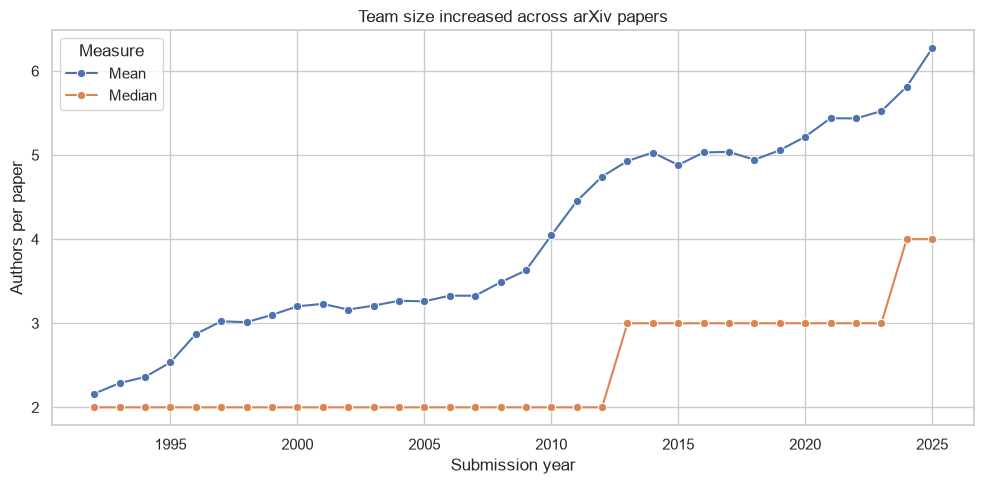

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=overall_by_year, x="submitted_year", y="mean_authors", marker="o", label="Mean", ax=ax)
sns.lineplot(data=overall_by_year, x="submitted_year", y="median_authors", marker="o", label="Median", ax=ax)
ax.set_title("Team size increased across arXiv papers")
ax.set_xlabel("Submission year")
ax.set_ylabel("Authors per paper")
ax.legend(title="Measure")
plt.tight_layout()

## Compare Fields Year by Year

Each row represents one field in one submission year, with the paper count, mean author count, and median author count. The comparison uses the eight fields with the most papers in the analysis.


In [ ]:
top_fields = analysis["field"].value_counts().head(8).index.tolist()

field_by_year = (
    analysis[analysis["field"].isin(top_fields)]
    .groupby(["field", "submitted_year"])["author_count"]
    .agg(papers="count", mean_authors="mean", median_authors="median")
    .reset_index()
    .sort_values(["submitted_year", "field"])
)

field_by_year.round(2)

,field,papers,early_mean,recent_mean,mean_change,early_median,recent_median
3,astro-ph,328205,4.34,12.63,8.30,3.0,5.0
4,physics,203688,3.00,6.21,3.21,2.0,4.0
0,cs,699114,2.43,4.56,2.13,2.0,4.0
2,cond-mat,340630,3.16,5.19,2.03,3.0,4.0
6,quant-ph,125762,2.54,4.21,1.68,2.0,3.0
5,hep-ph,140465,2.49,3.62,1.13,2.0,3.0
1,math,562290,1.70,2.24,0.54,1.0,2.0
7,hep-th,111043,2.07,2.56,0.49,2.0,2.0


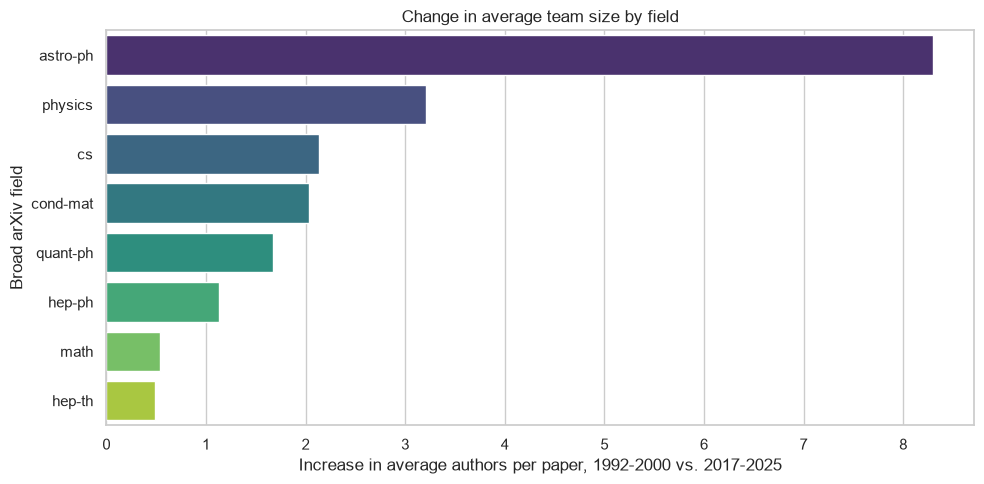

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(
    data=field_by_year,
    x="submitted_year",
    y="mean_authors",
    hue="field",
    ax=ax,
)
ax.set_title("Mean team size by broad arXiv field")
ax.set_xlabel("Submission year")
ax.set_ylabel("Mean authors per paper")
ax.legend(title="Field", ncol=2)
plt.tight_layout()

## Field Trends Over Time

This plot uses the median team size so the pattern is not dominated by a small number of huge collaboration papers.


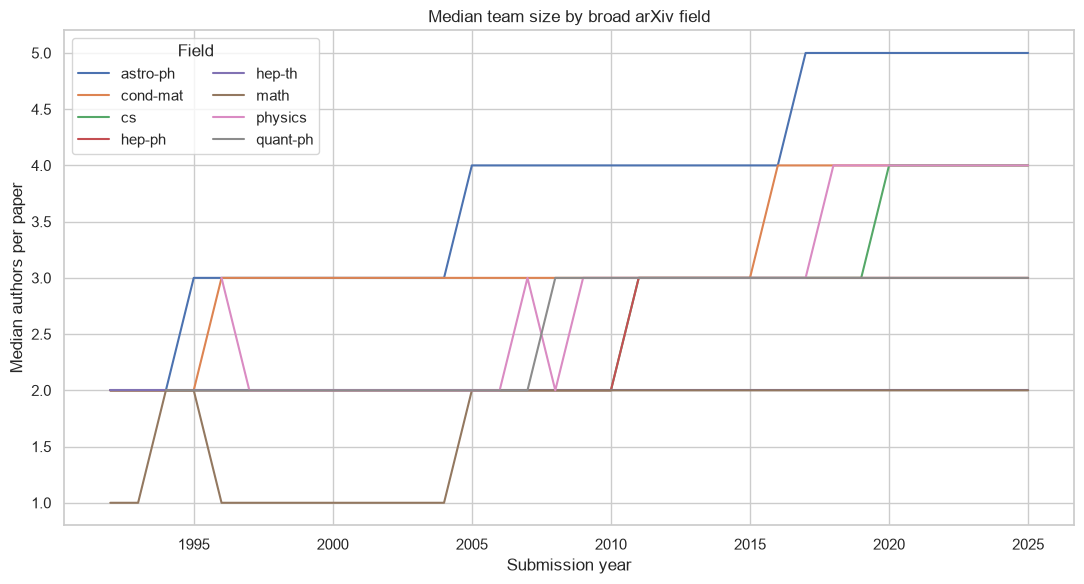

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))
sns.lineplot(
    data=field_by_year,
    x="submitted_year",
    y="median_authors",
    hue="field",
    ax=ax,
)
ax.set_title("Median team size by broad arXiv field")
ax.set_xlabel("Submission year")
ax.set_ylabel("Median authors per paper")
ax.legend(title="Field", ncol=2)
plt.tight_layout()

## Main Takeaways

- The yearly table shows how team size varies over time within each field.
- The mean and median describe different aspects of team size; a rising mean with a stable median can reflect growth concentrated in large collaborations.
- Paper counts show how many observations support each field's result in each year.
- The summary below reports the first and last observed years; the 2026 results describe a partial year.

Use the yearly mean and median trends to answer whether team sizes increased and how the pattern differs by field.


In [ ]:
summary_years = overall_by_year.sort_values("submitted_year")
start_row = summary_years.iloc[0]
end_row = summary_years.iloc[-1]

print("Yearly team-size summary:")
print(
    f"From {int(start_row['submitted_year'])} to {int(end_row['submitted_year'])}, "
    f"the average team size changed from "
    f"{start_row['mean_authors']:.1f} to {end_row['mean_authors']:.1f} authors per paper."
)
print(
    f"The median team size changed from {start_row['median_authors']:g} "
    f"to {end_row['median_authors']:g} authors per paper."
)
print(
    f"The field table contains {len(field_by_year):,} yearly results "
    f"across {len(top_fields)} fields."
)

Easy summary:
From 1992 to 2025, the average team size rose from 2.2 to 6.3 authors per paper.
The median team size rose from 2 to 4 authors per paper.
Among the largest fields, astro-ph changed the most, while hep-th changed the least.
